# Data Evaluation: User Study

## 0. Setup

In [ ]:
import pandas as pd
import matplotlib as mpl
%matplotlib inline

data_df = pd.read_csv('../ma-eval/protocol-data.csv')
data_df

,participant,p_id,date,group,s_iss_miro,s_tp_miro,s_fp_miro,s_iss_pixie,s_tp_pixie,s_fp_pixie,p_ans_miro,p_ans_pixie,p_right_miro,p_right_pixie,s_sob_miro,s_sob_pixie
0,2,PA40344,2026-06-29,AP,4,4,0,2,2,0,6,6,3,3.0,NaN,NaN
1,5,MA7125,2026-06-30,AM,4,1,3,2,2,0,4,3,3,2.0,NaN,NaN
2,21,MA26593,2026-07-07,AM,1,1,0,0,0,0,3,4,2,0.0,NaN,NaN
3,20,PB3394,2026-07-06,BP,2,2,0,0,0,0,6,6,6,5.0,NaN,NaN
4,14,PA4076,2026-07-02,AP,1,1,0,5,4,1,6,4,5,4.0,NaN,NaN
5,16,PB46220,2026-07-02,BP,5,4,1,1,1,0,5,3,5,2.0,NaN,NaN
6,6,PA45003,2026-06-30,AP,2,2,0,1,1,0,3,4,2,4.0,NaN,NaN
7,4,PB54700,2026-06-30,BP,3,3,0,1,1,0,6,3,6,2.0,NaN,NaN
8,7,MB24145,2026-06-30,BM,3,3,0,2,1,1,1,3,1,1.0,NaN,NaN
9,15,MB10509,2026-07-02,BM,2,2,0,1,1,1,3,5,2,5.0,NaN,NaN


## 1. Data Exploration

### Total Numbers of Issues/Answered Questions

includes incorrect answers

In [17]:
total_counts_pacing = [
    'p_ans_miro',
    'p_ans_pixie',
]
correct_counts_pacing = [
    'p_right_miro',
    'p_right_pixie'
]
#num_data_df = data_df[num_data_cols]
#num_data_df.index = data_df['p_id']
#plot = num_data_df.plot.pie(subplots=True, figsize=(5, 5))

#### Distribution of Total Number of Answered Questions Across Participants By Tool

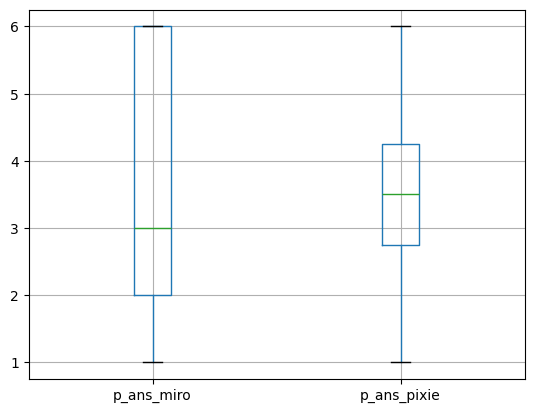

In [18]:
total_pacing_boxplot = data_df.boxplot(column=total_counts_pacing)

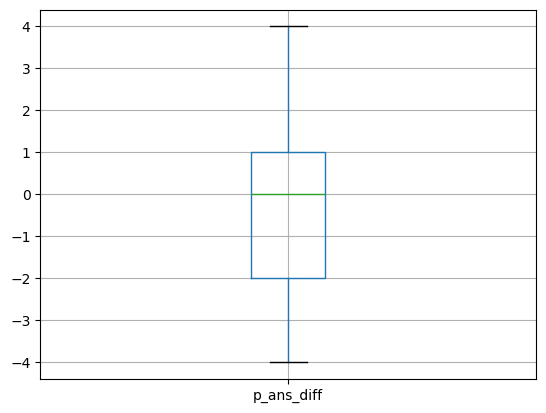

In [19]:
data_df['p_ans_diff'] = data_df['p_ans_pixie'] - data_df['p_ans_miro']
pacing_diff = data_df.boxplot(column=['p_ans_diff'])

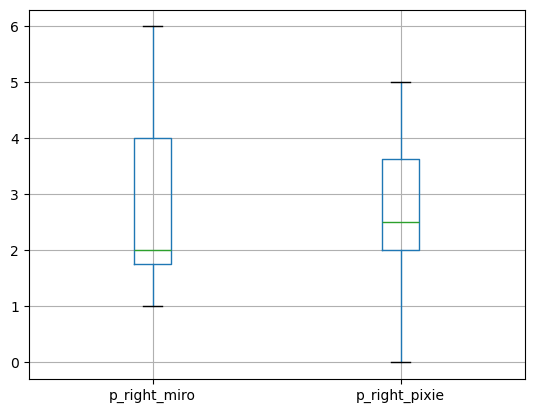

In [20]:
pacing_rights = data_df.boxplot(column=['p_right_miro', 'p_right_pixie'])

In [21]:
data_df[['p_right_miro', 'p_right_pixie']].describe()

,p_right_miro,p_right_pixie
count,24.000000,24.000000
mean,2.791667,2.625000
std,1.718927,1.353337
min,1.000000,0.000000
25%,1.750000,2.000000
50%,2.000000,2.500000
75%,4.000000,3.625000
max,6.000000,5.000000


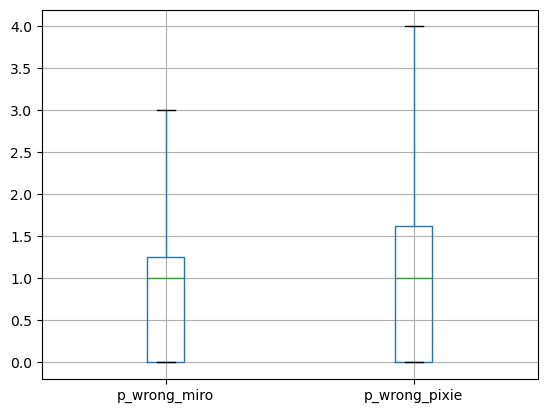

In [23]:
data_df['p_wrong_pixie'] = data_df['p_ans_pixie'] - data_df['p_right_pixie']
data_df['p_wrong_miro'] = data_df['p_ans_miro'] - data_df['p_right_miro']
pacing_wrongs = data_df.boxplot(column=['p_wrong_miro', 'p_wrong_pixie'])

In [24]:
data_df[['p_wrong_miro', 'p_wrong_pixie']].describe()

,p_wrong_miro,p_wrong_pixie
count,24.000000,24.000000
mean,0.916667,1.000000
std,0.974308,1.073394
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,1.250000,1.625000
max,3.000000,4.000000


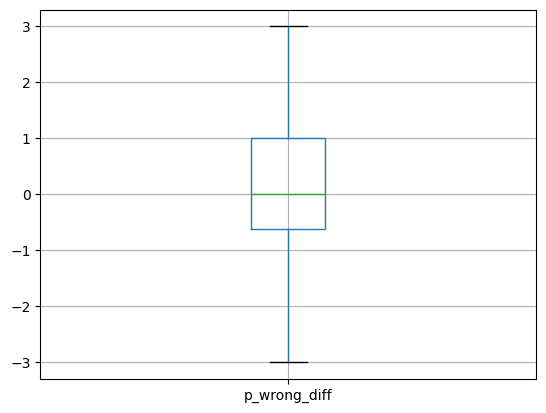

In [25]:
data_df['p_wrong_diff'] = data_df['p_wrong_pixie'] - data_df['p_wrong_miro']
pacing_wrongs = data_df.boxplot(column=['p_wrong_diff'])

In [26]:
data_df['p_wrong_diff'].describe()

count    24.000000
mean      0.083333
std       1.185663
min      -3.000000
25%      -0.625000
50%       0.000000
75%       1.000000
max       3.000000
Name: p_wrong_diff, dtype: float64

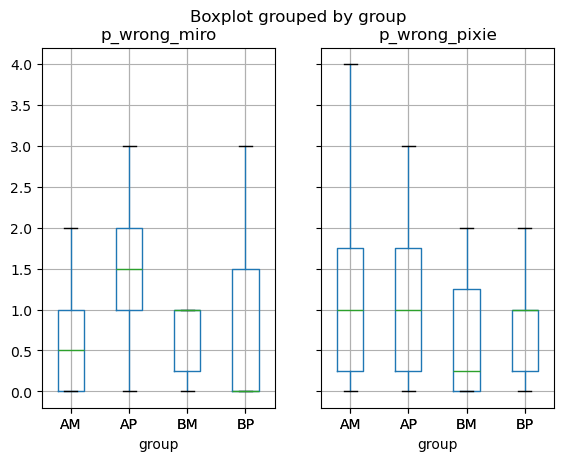

In [27]:
pacing_wrongs_grouped = data_df.boxplot(column=['p_wrong_miro', 'p_wrong_pixie'], by='group')

### Timeseries

In [62]:
timeseries_data_df = pd.read_csv('../eval-toolchain/time_series/all.csv')
timeseries_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
0,PA40344,AP,solvability_pixie,LA_3,01:27:30,STA,NaN,0
1,PA40344,AP,solvability_pixie,LA_3,01:27:44,OBS,pathfinding start-room after boss,14
2,PA40344,AP,solvability_pixie,LA_3,01:28:08,vb,ath blocked to boss,38
3,PA40344,AP,solvability_pixie,LA_3,01:28:45,OBS,successive pathfinding,75
4,PA40344,AP,solvability_pixie,LA_3,01:28:56,vb,oftlock 14,86
...,...,...,...,...,...,...,...,...
819,PA38184,AP,pacing_miro,LA_2,14:43:59,Q2A,A takes longer than B,162
820,PA38184,AP,pacing_miro,LA_2,14:44:08,Q4A,room 15,171
821,PA38184,AP,pacing_miro,LA_2,14:45:09,Q3A,"no, B has more enemies than C",232
822,PA38184,AP,pacing_miro,LA_2,14:46:07,Q5A,21-2 to 21-3,290


#### Timeseries: Answers

In [63]:
answers_data_df = timeseries_data_df[timeseries_data_df['tag'].isin(['Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A'])]
answers_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
11,PA40344,AP,pacing_pixie,LA_1,01:43:52,Q1A,q1 not steadily increasing,41
12,PA40344,AP,pacing_pixie,LA_1,01:45:10,Q2A,b shorter than a,119
13,PA40344,AP,pacing_pixie,LA_1,01:45:36,Q3A,more enemies in b than c,145
14,PA40344,AP,pacing_pixie,LA_1,01:46:51,Q4A,miniboss 18 or 7,220
15,PA40344,AP,pacing_pixie,LA_1,01:47:17,Q5A,9-3 to 5 sharpest increase,246
...,...,...,...,...,...,...,...,...
813,PA38184,AP,pacing_pixie,LA_1,14:37:13,Q2A,same length,124
819,PA38184,AP,pacing_miro,LA_2,14:43:59,Q2A,A takes longer than B,162
820,PA38184,AP,pacing_miro,LA_2,14:44:08,Q4A,room 15,171
821,PA38184,AP,pacing_miro,LA_2,14:45:09,Q3A,"no, B has more enemies than C",232


##### Distribution of Answer Events Across Time

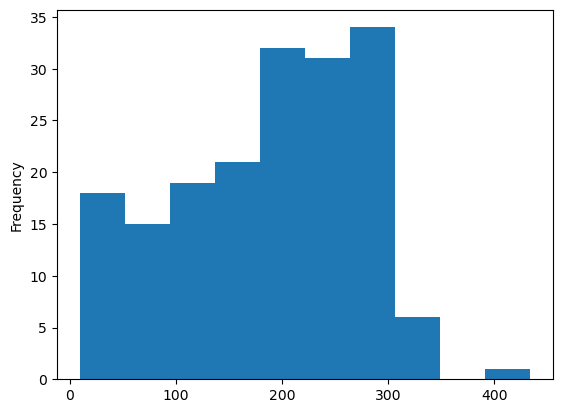

In [64]:
ax3 = answers_data_df['timedelta'].plot.hist()